# 1. 데이터 로드 및 병합
- 7개의 원본 CSV를 로드하고 하나의 Master DataFrame으로 병합합니다.

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

def load_and_merge():
    files = {
        '기본정보': '기본정보.csv', '면적정보': '면적정보.csv', '시설정보': '시설정보.csv',
        '운영정보': '운영정보.csv', '위치정보': '위치정보.csv', '장기수선': '장기수선.csv', '관리비': '관리비.csv'
    }
    dfs = {}
    for name, filename in files.items():
        path = os.path.join(DATA_DIR, filename)
        try:
            dfs[name] = pd.read_csv(path, encoding='utf-8')
        except UnicodeDecodeError:
            dfs[name] = pd.read_csv(path, encoding='cp949')

    if '면적정보' in dfs:
        area_df = dfs['면적정보']

        # 데이터 오류 수정 1: A13881302 단지의 한 행이 주거전용면적(세부)=84083.00으로 기입돼 있음.
        # 같은 단지의 다른 행(84.83)과 비교하면 소수점이 빠지며 자릿수가 잘못 기입된 오류로 판단해,
        # 해당 행의 세대수(1세대)를 84.83 행에 합산하고 오류 행은 제거한다.
        wrong_row = (area_df['단지코드'] == 'A13881302') & (area_df['주거전용면적(세부)'] == 84083.00)
        target_row = (area_df['단지코드'] == 'A13881302') & (area_df['주거전용면적(세부)'] == 84.83)
        area_df.loc[target_row, '세대수'] += area_df.loc[wrong_row, '세대수'].sum()
        area_df = area_df.loc[~wrong_row].reset_index(drop=True)

        # 데이터 오류 수정 2: 위 수정 후에도 A13881302의 주거전용면적(단지합계)=109728.83은
        # 관리비부과면적(33471.01)보다 3배 이상 크고(전용면적이 관리비부과면적보다 큰 것은 물리적으로 비정상),
        # 세부 행(전용면적 x 세대수)의 합(약 25,730.66)과도 맞지 않아 오류로 판단한다.
        # 정확한 원본 값을 확인할 방법이 없어, 세부 행 기준 합으로 보수적으로 대체한다.
        mask_a13881302 = area_df['단지코드'] == 'A13881302'
        corrected_total_area = (
            area_df.loc[mask_a13881302, '주거전용면적(세부)'] * area_df.loc[mask_a13881302, '세대수']
        ).sum()
        area_df.loc[mask_a13881302, '주거전용면적(단지합계)'] = corrected_total_area

        dfs['면적정보'] = area_df.drop_duplicates(subset=['단지코드']).drop(columns=['주거전용면적(세부)', '세대수'], errors='ignore')

    static_df = dfs['기본정보']
    for table_name in ['면적정보', '시설정보', '운영정보', '위치정보']:
        df_to_merge = dfs[table_name]
        cols_to_use = [col for col in df_to_merge.columns if col not in static_df.columns or col == '단지코드']
        static_df = pd.merge(static_df, df_to_merge[cols_to_use], on='단지코드', how='left')
    
    ts_df = dfs['관리비']
    repair_df = dfs['장기수선']
    join_keys = ['단지코드', '발생년월(YYYYMM)']
    cols_to_use = [col for col in repair_df.columns if col not in ts_df.columns or col in join_keys]
    ts_df = pd.merge(ts_df, repair_df[cols_to_use], on=join_keys, how='left')
    
    raw_master_df = pd.merge(ts_df, static_df, on='단지코드', how='left')
    return raw_master_df

raw_master_df = load_and_merge()
print(f"병합 완료된 원본 데이터 크기: {raw_master_df.shape}")
raw_master_df.head()

병합 완료된 원본 데이터 크기: (147240, 87)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 1-1. 세대수 데이터 보정

`기본정보.csv`의 `세대수`와 `면적정보.csv`(평형별 세대수의 단지 합계)가 서로 다른 단지를 전수 조사한 결과 **83개 단지**에서 불일치가 확인됐습니다(양방향 모두 존재 — 기본정보가 더 작은 경우와 더 큰 경우가 섞여 있음).

외부 참조자료(`서울시 공동주택 아파트 정보(위도경도 포함)` CSV, 아파트 단지별 상세 정보를 담은 공개 자료의 `k-전체세대수` 컬럼)로 교차 검증해, **79개 단지**는 참조자료 값으로 `세대수`를 보정합니다. 나머지 4개 단지 중 3개(`A13528105` 개포1차2차우성, `A10027289` 센트라스, `A13402304` 천호태영임대)는 참조자료 파일에 해당 단지 행 자체가 없어 값을 가져오지 못했던 것으로 확인되어, 정확한 세대수(각각 1,140세대·2,529세대·649세대)를 별도로 확인해 보정합니다(총 **82개 단지** 보정). 나머지 1개 단지(`A13527017`)는 여전히 참조자료 값이 없어 원본을 유지합니다(추후 별도 확인 필요).

또한 `면적정보.csv`에서 `A13881302`(거여현대3차) 단지에 두 가지 오류를 확인해 위 코드 셀에서 처리했습니다.
1. 한 행이 `주거전용면적(세부)=84083.00`으로 기입돼 있던 것 — 같은 단지의 다른 행(`84.83`)과 비교했을 때 소수점이 빠지며 자릿수가 잘못 기입된 오류로 판단해, 해당 행의 세대수(1세대)를 `84.83` 행에 합산하고 오류 행은 제거했습니다.
2. 위 수정 후에도 `주거전용면적(단지합계)=109728.83`이 `관리비부과면적`(33471.01)보다 3배 이상 크고(전용면적이 관리비부과면적보다 큰 것은 물리적으로 비정상) 세부 행 기준 합(약 25,730.66)과도 크게 어긋나 있어 별도 오류로 판단, 정확한 원본 값을 확인할 방법이 없어 세부 행 기준 합으로 보수적으로 대체했습니다.

In [2]:
# 세대수 보정 매핑: 단지코드 -> 정확한 세대수
# 출처: 서울시 공동주택 아파트 정보(위도경도 포함) 참조자료의 `k-전체세대수` 컬럼(79개) +
#      참조자료에 행 자체가 없어 별도로 확인한 3개 단지(A13528105, A10027289, A13402304)
# 기본정보.csv 세대수와 면적정보.csv 세대수 합계가 불일치한 83개 단지 중, 82개 단지 포함
HOUSEHOLD_COUNT_CORRECTIONS = {
    'A10023788': 276, 'A10023815': 249, 'A10024408': 306, 'A10024891': 913,
    'A10025013': 959, 'A10026004': 607, 'A10026036': 927, 'A10026710': 208,
    'A10026748': 1976, 'A10027851': 940, 'A10028042': 245, 'A10028172': 716,
    'A10028201': 182, 'A10045302': 3118, 'A10086301': 286, 'A10095501': 297,
    'A12009304': 554, 'A12009305': 768, 'A12201102': 300, 'A12275501': 254,
    'A13003406': 741, 'A13009002': 1224, 'A13009206': 445, 'A13070101': 190,
    'A13186305': 858, 'A13188406': 345, 'A13203408': 690, 'A13276417': 489,
    'A13307002': 457, 'A13475001': 191, 'A13484003': 277, 'A13522006': 1163,
    'A13522008': 2565, 'A13528004': 2436, 'A13528005': 372, 'A13552001': 1513,
    'A13572601': 239, 'A13582002': 548, 'A13590204': 826, 'A13593908': 1623,
    'A13607302': 354, 'A13615002': 453, 'A13679902': 201, 'A13703011': 256,
    'A13707006': 293, 'A13792001': 2390, 'A13812004': 249, 'A13812005': 889,
    'A13822902': 555, 'A13872503': 523, 'A13879102': 3930, 'A13880406': 839,
    'A13881204': 672, 'A13977913': 2634, 'A14070302': 589, 'A14085002': 554,
    'A14086001': 578, 'A14319012': 1177, 'A15003001': 271, 'A15005402': 826,
    'A15007002': 233, 'A15089421': 1584, 'A15101101': 688, 'A15101507': 960,
    'A15183001': 387, 'A15210105': 252, 'A15303103': 233, 'A15383308': 1226,
    'A15383702': 786, 'A15383905': 640, 'A15703313': 1670, 'A15722010': 442,
    'A15776715': 1146, 'A15780705': 1998, 'A15780806': 2412, 'A15785612': 1000,
    'A15805503': 1382, 'A15882104': 183, 'A41279927': 335,
    'A13528105': 1140, 'A10027289': 2529, 'A13402304': 649,
}

def correct_household_counts(df, correction_map=HOUSEHOLD_COUNT_CORRECTIONS):
    df = df.copy()
    corrected = df['단지코드'].map(correction_map)
    n_complexes = df.loc[corrected.notna(), '단지코드'].nunique()
    df['세대수'] = corrected.fillna(df['세대수'])
    print(f"세대수 보정 적용: {n_complexes}개 단지")
    return df

raw_master_df = correct_household_counts(raw_master_df)
raw_master_df[raw_master_df['단지코드'].isin(HOUSEHOLD_COUNT_CORRECTIONS)][['단지코드', '세대수']].drop_duplicates('단지코드').head()

세대수 보정 적용: 82개 단지


,단지코드,세대수
324,A10086301,286.0
348,A10028201,182.0
432,A10045302,3118.0
540,A10095501,297.0
624,A10023788,276.0


# 2. 데이터 전처리
- 2-1. 결측치 처리
- 2-2. 칼럼 삭제
- 2-3. 파생변수 생성
- 2-4. 다중공선성 확인 (VIF)

## 2-1. 결측치 처리
- `경비관리-인원`(0.49%, 12개 단지) 결측치를 **세대수 사분위 구간 × 관리방식 그룹 중앙값**으로 대치합니다.
- 그 외 관리비/시설 항목의 0값들(난방비, 임대세대수 등)은 결측이 아니라 정당한 값(구조적 0·이벤트성 0)으로 판단되어 별도 처리하지 않습니다.
- 근거 및 검증 과정: `문서/작업과정/결측치_처리_점검_20260826.md`

In [3]:
def handle_missing_values(df):
    df = df.copy()
    missing_codes = df.loc[df['경비관리-인원'].isna(), '단지코드'].unique()

    complexes = df.drop_duplicates('단지코드').copy()
    q1, q2, q3 = complexes['세대수'].quantile([.25, .5, .75])

    def bucket_size(x):
        if x <= q1:
            return '소형'
        if x <= q2:
            return '중소형'
        if x <= q3:
            return '중대형'
        return '대형'

    complexes['세대수구간'] = complexes['세대수'].apply(bucket_size)
    df = df.merge(complexes[['단지코드', '세대수구간']], on='단지코드', how='left')

    group_median = (
        df.dropna(subset=['경비관리-인원'])
        .groupby(['세대수구간', '관리방식'])['경비관리-인원']
        .median()
    )

    def impute_guard_staff(row):
        if pd.notna(row['경비관리-인원']):
            return row['경비관리-인원']
        key = (row['세대수구간'], row['관리방식'])
        if key in group_median.index:
            return group_median.loc[key]
        return group_median.loc[row['세대수구간']].median()  # fallback: 관리방식 무시하고 세대수구간 전체 중앙값

    df['경비관리-인원'] = df.apply(impute_guard_staff, axis=1)
    df = df.drop(columns=['세대수구간'])

    print(f"결측치 대치 완료: {len(missing_codes)}개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치")
    print(f"대치 후 남은 결측 수: {df['경비관리-인원'].isna().sum()}")
    return df

raw_master_df = handle_missing_values(raw_master_df)
raw_master_df.head()

결측치 대치 완료: 12개 단지의 경비관리-인원 결측을 그룹 중앙값으로 대치
대치 후 남은 결측 수: 0


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,제세공과금,피복비,교육훈련비,차량유지비,그밖의부대비용,...,경비관리-인원,경비관리-계약업체,청소관리-관리방식,청소관리-인원,청소관리-계약업체,음식물 처리방법,소독관리-관리방식,소독관리-계약업체,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,65740,0,0,0,341860,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,70920,0,71000,0,326160,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,53530,0,50000,0,711840,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,54170,0,50000,0,315660,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,62900,0,0,0,398410,...,4.0,에스원,위탁관리,4,좋은서비스,차량수거방식,위탁관리,좋은서비스,37.573567,126.972151


## 2-2. 칼럼 삭제
- 병합된 데이터프레임에서 불필요한 칼럼을 삭제합니다.
- `장충금 적립률`은 2026-08-26 팀 결정으로 삭제 목록에 추가했습니다 (0값 비율의 원인을 설명할 수 없어 삭제 — 근거는 위 결측치 처리 점검 문서 참고).

In [4]:
def preprocess_data(df):
    cols_to_drop = [
        '차량유지비', '지능형네트워크유지비', '재해예방비', '가스사용료(공용)', '가스사용료(전용)', '기타', '제세공과금', '교육훈련비', '시설유지비', '안전점검비', '위탁관리수수료', '급탕비(공용)', '수도료(공용)', 'TV수신료', '정화조오물수수료', '선관위운영비',
        '시공사', '주택관리업자',
        '건물구조', '전기-수전용량', '전기-세대전기계약방식', '승강기관리-관리방식', 'CCTV대수', '부대복리시설', '홈네트워크',
        '경비관리-계약업체', '청소관리-계약업체', '음식물 처리방법', '소독관리-계약업체', '일반관리-관리방식', '경비관리-관리방식', '청소관리-관리방식', '소독관리-관리방식',
        '입주자기여수익', '공동기여수익',
        '장충금 적립률',  # 2026-08-26 팀 결정: 0비율 원인 설명 불가로 삭제
    ]
    existing_cols = [col for col in cols_to_drop if col in df.columns]
    df_cleaned = df.drop(columns=existing_cols)
    
    print(f"삭제된 칼럼 수: {len(existing_cols)}개")
    print(f"전처리 완료 후 최종 남은 데이터 크기: {df_cleaned.shape}")
    return df_cleaned

final_df = preprocess_data(raw_master_df)
final_df.head()

삭제된 칼럼 수: 34개
전처리 완료 후 최종 남은 데이터 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계,인건비,제사무비,피복비,그밖의부대비용,청소비,경비비,소독비,...,주거전용면적(단지합계),승강기대수,총주차대수,최고층수,지하층수,일반관리-인원,경비관리-인원,청소관리-인원,위도,경도
0,A11007001,202101,53343583.0,21552672,248500.0,0,341860,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
1,A11007001,202102,53189158.0,21552614,248100.0,0,326160,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
2,A11007001,202103,53228835.0,21552616,228500.0,0,711840,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
3,A11007001,202104,51995807.0,20485440,243900.0,0,315660,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151
4,A11007001,202105,52384391.0,20494660,231100.0,0,398410,9046000,18157174,250000,...,22444.8,5,315,16,3,5,4.0,4,37.573567,126.972151


## 2-3. 파생변수 생성
- 비용 항목 24개 + 시설·인원 5개(승강기대수, 총주차대수, 일반/경비/청소관리-인원)를 `관리비부과면적` 기준으로 정규화(`_perm2`)하여 `per_df`를 만듭니다.
- `동수`, `분양세대수`/`임대세대수`는 이번엔 파생변수를 만들지 않고 원값 그대로 둡니다.
- 상세 근거: [의사결정 로그](https://app.notion.com/p/3c9831afe087812ba44bfe9b8fad522e)

In [5]:
# 관리비부과면적당 단가로 환산할 금액(비용) 컬럼 목록
AMOUNT_COLS = [
    # 관리비.csv 유래
    '공용관리비계', '인건비', '제사무비', '피복비', '그밖의부대비용', '청소비', '경비비', '소독비',
    '승강기유지비', '수선비', '개별사용료계', '난방비(공용)', '난방비(전용)', '급탕비(전용)',
    '전기료(공용)', '전기료(전용)', '수도료(전용)', '생활폐기물수수료', '입대의운영비', '건물보험료',
    # 장기수선.csv 유래
    '장충금 월부과액', '장충금 월사용액', '장충금 총적립금액', '잡수입 월수입금액',
    # 시설·인원 수 (2026-08-27 팀 결정: 세대수 대신 관리비부과면적 기준으로 정규화. 동수는 제외)
    '승강기대수', '총주차대수', '일반관리-인원', '경비관리-인원', '청소관리-인원',
]

def calc_per_area(df, amount_cols=AMOUNT_COLS, area_col='관리비부과면적'):
    cols = [c for c in amount_cols if c in df.columns]
    df_perm2 = df.copy()
    df_perm2[cols] = df[cols].div(df[area_col], axis=0)
    df_perm2 = df_perm2.rename(columns={c: f'{c}_perm2' for c in cols})
    return df_perm2

per_df = calc_per_area(final_df)
print(f"per_df 크기: {per_df.shape}")
per_df.head()

per_df 크기: (147240, 53)


,단지코드,발생년월(YYYYMM),공용관리비계_perm2,인건비_perm2,제사무비_perm2,피복비_perm2,그밖의부대비용_perm2,청소비_perm2,경비비_perm2,소독비_perm2,...,주거전용면적(단지합계),승강기대수_perm2,총주차대수_perm2,최고층수,지하층수,일반관리-인원_perm2,경비관리-인원_perm2,청소관리-인원_perm2,위도,경도
0,A11007001,202101,1389.459752,561.390304,6.472770,0.0,8.904552,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
1,A11007001,202102,1385.437387,561.388793,6.462351,0.0,8.495608,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
2,A11007001,202103,1386.470869,561.388845,5.951823,0.0,18.541556,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
3,A11007001,202104,1354.353739,533.591723,6.352952,0.0,8.222111,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151
4,A11007001,202105,1364.475328,533.831880,6.019546,0.0,10.377531,235.62446,472.94653,6.511841,...,22444.8,0.00013,0.008205,16,3,0.00013,0.000104,0.000104,37.573567,126.972151


## per_df 정리 - 비아파트 단지 제외 후 `단지분류` 컬럼 삭제
- `단지분류`가 `주상복합`, `연립주택`, `도시형 생활주택(주상복합)`, `도시형 생활주택(아파트)`, `다세대`인 행을 모두 제거하고 `아파트`만 남긴다.
- 필터링이 끝나면 모든 행이 `아파트`로 동일해져 `단지분류` 컬럼이 더 이상 정보를 담지 않으므로 삭제한다.
- **이 필터링은 `per_df` 생성 직후, VIF·PCA·이후 분석 이전에 적용한다** — 그래야 뒤따르는 모든 분석이 아파트만 대상으로 한 결과가 된다.

In [6]:
NON_APT_TYPES = ['주상복합', '연립주택', '도시형 생활주택(주상복합)', '도시형 생활주택(아파트)', '다세대']

before_shape = per_df.shape
per_df = per_df[~per_df['단지분류'].isin(NON_APT_TYPES)].reset_index(drop=True)
print(f"비아파트 제외 전: {before_shape} -> 제외 후: {per_df.shape}")

per_df = per_df.drop(columns=['단지분류'])
print(f"'단지분류' 컬럼 삭제 후 per_df 크기: {per_df.shape}")
print(f"컬럼 수: {per_df.shape[1]}")
print(f"단지코드(고유 단지) 수: {per_df['단지코드'].nunique()}")

비아파트 제외 전: (147240, 53) -> 제외 후: (133380, 53)
'단지분류' 컬럼 삭제 후 per_df 크기: (133380, 52)
컬럼 수: 52


단지코드(고유 단지) 수: 2223


## 2-4. 다중공선성 확인 (VIF)

**VIF (Variance Inflation Factor)**
- 각 독립변수 하나를 종속변수처럼 놓고 나머지 모든 독립변수로 회귀시켰을 때의 결정계수($R_i^2$)를 이용합니다.

$$VIF_i = \frac{1}{1 - R_i^2}$$

- $R_i^2$가 1에 가까울수록(다른 변수들로 거의 완벽히 설명됨) VIF는 무한대로 발산합니다.
- 단순 상관계수와 달리 **다른 모든 변수를 동시에 고려한 상태에서** 해당 변수가 얼마나 "중복 정보"인지를 봅니다.
- 해석 기준(일반적 관행): VIF < 5 문제 없음 / 5 ≤ VIF < 10 주의 / VIF ≥ 10 심각한 다중공선성

`per_df`의 면적당단가(`_perm2`) 파생변수와 규모/입지/연식 변수들 간 다중공선성을 VIF로 확인합니다.

In [7]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

def calc_vif(df, cols):
    X = add_constant(df[cols].dropna())
    vif_df = pd.DataFrame({
        'variable': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
    })
    vif_df = vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False).reset_index(drop=True)
    return vif_df

perm2_cols = [c for c in per_df.columns if c.endswith('_perm2')]

# 건물 사용연수: 데이터 발생시점(발생년월)을 기준으로 사용승인일로부터 경과한 연수
approval_date = pd.to_datetime(per_df['사용승인일'].astype(str), format='%Y%m%d')
record_date = pd.to_datetime(per_df['발생년월(YYYYMM)'].astype(str) + '01', format='%Y%m%d')
per_df['사용연수'] = (record_date - approval_date).dt.days / 365.25

# 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로 발생한 음수는 0으로 대체
negative_age_count = (per_df['사용연수'] < 0).sum()
per_df.loc[per_df['사용연수'] < 0, '사용연수'] = 0
print(f"사용연수 음수 {negative_age_count}행을 0으로 대체")

# 평균전용면적: 세대 하나당 평균 전용면적 (세대수와는 다른 정보 - 기획안의 "면적" 매칭 기준에 대응)
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

# 합계(계) 컬럼은 하위 세부 항목들의 선형결합이라 구조적으로 VIF를 부풀리므로 제외
SUM_COLS_TO_EXCLUDE = ['개별사용료계_perm2', '공용관리비계_perm2']
EXTRA_COLS = ['세대수', '최고층수', '지하층수', '위도', '경도', '사용연수', '평균전용면적']
vif_cols = [c for c in perm2_cols if c not in SUM_COLS_TO_EXCLUDE] + EXTRA_COLS

vif_df = calc_vif(per_df, vif_cols)
print(f"VIF 계산 대상: {len(vif_cols)}개 변수 (세부항목 27개 + 규모/입지/연식 변수 {len(EXTRA_COLS)}개), 샘플 수: {per_df[vif_cols].dropna().shape[0]}")
vif_df

사용연수 음수 97행을 0으로 대체


VIF 계산 대상: 34개 변수 (세부항목 27개 + 규모/입지/연식 변수 7개), 샘플 수: 133380


,variable,VIF
0,경비비_perm2,4.303369
1,경비관리-인원_perm2,4.183636
2,청소비_perm2,3.544045
3,인건비_perm2,3.541151
4,사용연수,3.177616
5,일반관리-인원_perm2,3.075311
6,청소관리-인원_perm2,2.913793
7,총주차대수_perm2,2.410988
8,급탕비(전용)_perm2,2.107881
9,난방비(전용)_perm2,1.812321


**결과 해석**
- 초기 29개 `_perm2` 변수 중 `개별사용료계_perm2`(43.2), `공용관리비계_perm2`(25.7) 등이 VIF 10을 초과 — 하위 세부 항목들의 **합계(선형결합)**라서 구조적으로 발생하는 문제입니다.
- 두 합계 컬럼을 제외하고 세부 항목 27개 + 규모/입지/연식 변수 7개(`세대수`, `최고층수`, `지하층수`, `위도`, `경도`, `사용연수`, `평균전용면적`) 총 34개로 재계산하면 **최댓값 4.30**로 전부 5 미만입니다.
- `사용연수` 음수 97행(0.07%)은 관리비 부과월이 사용승인일보다 앞선 데이터 품질 이슈로, 0으로 대체했습니다. (아파트만 필터링한 뒤라 이전 108행보다 줄었습니다.)
- `평균전용면적`(주거전용면적(단지합계) ÷ 세대수)은 VIF **1.72**로 `세대수`(1.54)와 여전히 독립적입니다 — "단지가 몇 세대인가"와 "세대 하나가 얼마나 큰가"는 서로 다른 정보라는 뜻입니다.
- **결론**: 모델링 시 합계 컬럼 2개는 제외하고, 나머지 34개 변수를 사용하는 것을 권장합니다.

In [8]:
# 3. PCA 검토: VIF를 통과한 34개 변수를 표준화
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_data = per_df[vif_cols].dropna()
X_scaled = StandardScaler().fit_transform(pca_data)
print(f'PCA 입력: {pca_data.shape[0]:,}행 × {pca_data.shape[1]}변수')

PCA 입력: 133,380행 × 34변수


In [9]:
# 90%는 최적값이 아니므로 여러 설명분산 기준을 함께 비교
pca = PCA().fit(X_scaled)
cumulative_variance = pca.explained_variance_ratio_.cumsum()
thresholds = [0.80, 0.85, 0.90, 0.95]
pca_thresholds = pd.DataFrame({
    '누적설명분산기준': thresholds,
    '필요주성분수': [int(np.searchsorted(cumulative_variance, t) + 1) for t in thresholds],
})
pca_thresholds.style.format({'누적설명분산기준': '{:.0%}'})

,누적설명분산기준,필요주성분수
0,80%,19
1,85%,22
2,90%,24
3,95%,28


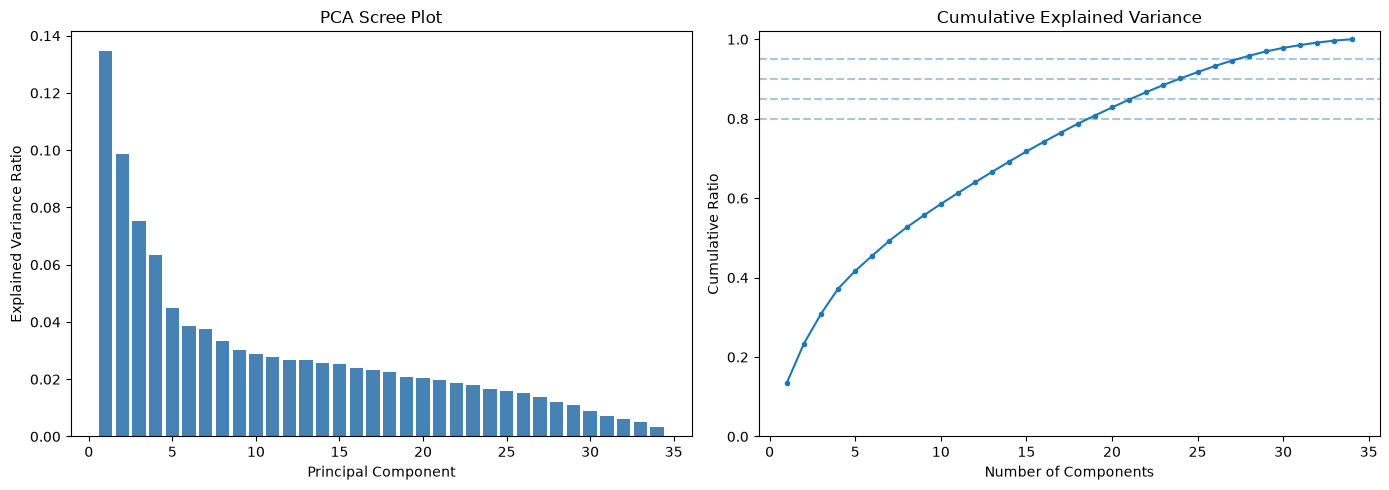

In [10]:
# 차원 축소 효과 확인
components = np.arange(1, len(vif_cols) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(components, pca.explained_variance_ratio_, color='steelblue')
axes[0].set(title='PCA Scree Plot', xlabel='Principal Component', ylabel='Explained Variance Ratio')
axes[1].plot(components, cumulative_variance, marker='o', markersize=3)
for threshold in thresholds:
    axes[1].axhline(threshold, linestyle='--', alpha=0.4)
axes[1].set(title='Cumulative Explained Variance', xlabel='Number of Components', ylabel='Cumulative Ratio', ylim=(0, 1.02))
plt.tight_layout()
plt.show()

## 3. PCA 검토 결과 해석

- 누적 설명분산 80%에는 19개, 85%에는 22개, 90%에는 24개, 95%에는 28개 주성분이 필요합니다. 90%는 수학적으로 정해진 최적값이 아니라 비교용 기준입니다.
- 90% 기준에서 34개가 24개로 줄어 압축 효과가 크지 않습니다. 현재 34개 변수는 VIF 검토를 통과했고 모델링에 과도한 수가 아니므로 PCA를 필수 전처리로 적용할 필요는 낮습니다.
- 각 주성분은 특정 원본 컬럼을 삭제한 결과가 아니라 원본 34개 변수 전체의 가중합입니다. PCA를 적용하면 관리비 항목별 영향 해석이 어려워집니다.
- K-means에서는 PCA가 거리 계산의 중복·노이즈를 줄일 수 있지만 필수는 아닙니다. **표준화한 원본 변수 K-means와 PCA K-means를 동일한 조건에서 비교**하고 군집 품질과 안정성이 실제로 개선될 때만 PCA를 채택합니다.
- 단지 유형을 군집화하려면 월별 133,380행을 그대로 사용하지 않고, 먼저 2,223개 단지(아파트만) 단위의 평균·변동성·추세 특성으로 집계해야 합니다.

# 4. 1단계 구조 군집 변수 준비

향후 K-Means로 "조건이 비슷한 단지"를 묶기 위해 단지의 기본 구조를 직접 설명하는 `세대수`, `평균전용면적`, `사용연수`를 사용한다. `세대수`는 단지 규모, `평균전용면적`은 대표 평형, `사용연수`는 연식을 나타낸다. `평균전용면적`은 `주거전용면적(단지합계) ÷ 세대수`로 계산한다.

## 지금까지의 변수 축소 과정 (34개 → 3개)

1단계 구조 군집 변수는 한 번에 3개로 정해진 것이 아니라, 단계별로 축소되며 매번 트레이드오프를 확인했다.

1. **VIF 통과 34개** (2-4절): `_perm2` 세부 항목 27개 + 규모·입지·연식 변수 7개(`세대수`·`최고층수`·`지하층수`·`위도`·`경도`·`사용연수`·`평균전용면적`), 최댓값 VIF 4.30으로 다중공선성 없음을 확인.
2. **34개 → 7개** (관리비·위치·운영방식 제외 원칙, 2026-08-31): 비용 변수(관리비와 순환논리 문제)와 위도·경도(공간 군집화 방지)를 제외해 `세대수`·`평균전용면적`·`사용연수`·`최고층수`·`지하층수`·`승강기대수_perm2`·`총주차대수_perm2` 7개로 압축.
3. **7개 → 5개** (2026-08-31, 최고층수·지하층수 제외): 4개 주요 부동산 플랫폼(네이버·KB·호갱노노·리치고)의 공통 검색 필터가 면적·세대수·연식뿐이라는 점을 근거로 제외. 실루엣은 0.176→0.215로 개선되지만 두 변수셋 간 군집 배정 ARI는 0.384에 그쳐 단지의 약 60%가 재배치되는 트레이드오프를 확인하고도, 플랫폼 정합성과 서비스 설명 용이성을 우선해 채택했다.
4. **5개 → 3개** (2026-09-01, 오늘): 아래 "팀 결정" 참고.

**2026-09-01 팀 결정: 1단계 구조 군집 입력을 3개 변수로 변경한다.**

- **선정 변수**: `세대수`, `평균전용면적`, `사용연수`
- **선정 근거**: 세 변수는 단지의 규모·평형·연식을 각각 나타내며, 소비자와 분석자가 모두 직관적으로 이해할 수 있는 공통 비교축이다.
- **비교 검증**: 최종 `per_df`의 동일한 2,223개 단지로 3·5·7변수를 다시 비교한 결과, 세 조합 모두 엘보우가 `k=5`를 지지했다. `k=5`의 Silhouette은 3변수 0.322, 5변수 0.215, 7변수 0.176으로 3변수가 가장 높았다.
- **트레이드오프 확인**: 3변수와 5변수 결과 간 ARI는 0.4259, 3변수와 7변수 결과 간 ARI는 0.2603이다 — 7→5 단계와 마찬가지로, 변수를 줄일수록 실루엣은 계속 개선되지만 인접 단계끼리도 군집 배정의 절반 가까이가 재배치되는 패턴이 반복된다. 이는 3변수가 통계적으로 "더 우월한" 군집화라는 근거가 아니라, 변수 수와 실루엣이 구조적으로 반비례하는 현상임을 뜻한다.
- **해석 가능성**: 3변수 군집은 결과와 시각화의 축이 동일하므로, 각 단지가 왜 해당 군집에 속했는지 별도의 합성축 없이 설명할 수 있다.
- **시설 변수의 위치**: `승강기대수_perm2`, `총주차대수_perm2`는 오늘 새로 제외한 변수이고, `최고층수`·`지하층수`는 어제(2026-08-31) 이미 제외된 상태였다 — 즉 오늘 결정은 "7개 → 3개"가 아니라 "(어제 확정한) 5개 → 3개"의 연속 축소다. 네 변수 모두 데이터에서 버리는 것은 아니며, 1단계 군집을 나누는 기준에서는 제외하고 군집별 특성 설명이나 관리비 차이 해석을 위한 참고 변수로 활용한다.
- **유의점**: 3변수 `k=5`의 최소 군집은 150개로 5변수의 262개보다 작지만, 별도의 3단계 재필터링을 진행하지 않는 현재 분석 범위에서는 군집 내 관리비 비교를 수행할 수 있는 규모다.

이번 선택은 PCA를 적용하지 않고 원 변수의 의미를 유지한다.

In [11]:
# 세대수·주거전용면적(단지합계)은 단지별 고정값이므로 단지 단위로 축약한 뒤 계산 (아파트만 필터링된 상태)
complex_df = per_df[['단지코드', '세대수', '주거전용면적(단지합계)']].drop_duplicates('단지코드').reset_index(drop=True)
complex_df['평균전용면적'] = complex_df['주거전용면적(단지합계)'] / complex_df['세대수']

print(f"단지 단위 데이터 크기: {complex_df.shape}")
complex_df.describe()

단지 단위 데이터 크기: (2223, 4)


,세대수,주거전용면적(단지합계),평균전용면적
count,2223.000000,2223.000000,2223.000000
mean,644.946919,49603.828724,78.130480
std,662.399026,55531.206350,22.804515
min,110.000000,2565.952000,13.795441
25%,252.000000,18790.928500,70.849899
50%,435.000000,33008.820000,79.609560
75%,782.500000,58927.165000,85.634857
max,9510.000000,734780.750000,228.950100


In [12]:
# `평균전용면적`을 per_df(월별, 아파트만)에도 추가 — 원본 소스 컬럼이 이미 row-level로 존재하므로 직접 계산
per_df['평균전용면적'] = per_df['주거전용면적(단지합계)'] / per_df['세대수']

print(f"per_df 크기: {per_df.shape}")
per_df[['단지코드', '세대수', '주거전용면적(단지합계)', '평균전용면적']].head()

per_df 크기: (133380, 54)


,단지코드,세대수,주거전용면적(단지합계),평균전용면적
0,A11005401,744.0,94981.45,127.663239
1,A11005401,744.0,94981.45,127.663239
2,A11005401,744.0,94981.45,127.663239
3,A11005401,744.0,94981.45,127.663239
4,A11005401,744.0,94981.45,127.663239


## 4-1. 3개 변수 분포 확인 (왜도, 극단값)

1단계 구조 군집 변수 3개(`세대수`, `평균전용면적`, `사용연수`)를 단지 단위로 정리하고, 각 변수의 왜도와 IQR 기준 극단값 개수를 확인한다. 1-1절의 세대수 보정과 비아파트 단지 제외가 모두 반영된 최종 `per_df`를 사용한다.

In [13]:
STEP1_COLS = ['세대수', '평균전용면적', '사용연수']
unit_df = per_df.groupby('단지코드')[STEP1_COLS].mean()

def count_iqr_outliers(s):
    q1, q3 = s.quantile([.25, .75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return int(((s < lower) | (s > upper)).sum())

dist_summary = pd.DataFrame({
    '평균': unit_df.mean(),
    '표준편차': unit_df.std(),
    '왜도': unit_df.skew(),
    '최솟값': unit_df.min(),
    '최댓값': unit_df.max(),
})
dist_summary['IQR기준_극단값_개수'] = [count_iqr_outliers(unit_df[c]) for c in STEP1_COLS]

print(f"단지 단위 데이터 크기: {unit_df.shape}")
dist_summary

단지 단위 데이터 크기: (2223, 3)


,평균,표준편차,왜도,최솟값,최댓값,IQR기준_극단값_개수
세대수,644.946919,662.399026,3.862171,110.000000,9510.000000,165
평균전용면적,78.130480,22.804515,0.497869,13.795441,228.950100,395
사용연수,22.136484,9.544573,0.035550,1.174949,52.237828,17


# 5. 이상치 처리

**원칙**: 데이터 오류로 확인된 값만 수정·제외하고, 실제 극단 단지는 유지한다. 대형·노후 단지처럼 실제로 존재하는 특성을 임의로 자르면 군집 구조가 왜곡될 수 있다.

## 5-1. 데이터 오류 확인

4-1절에서 확인한 3개 변수의 극단값을 실제 단지명과 함께 확인한다.

| 변수 | 확인한 내용 | 판단 |
|---|---|---|
| 세대수 | 1-1절의 세대수 불일치 보정을 반영한 뒤 상위 단지를 재확인 | 실존 초대형 단지로 확인되어 **유지** |
| 평균전용면적 | 세대수 보정 및 A13881302 면적 오류 전처리를 반영한 뒤 상위 단지를 재확인 | 실존 대형 평형 단지로 확인되어 **유지** |
| 사용연수 | 분포가 거의 대칭이고 극단값 비율이 낮음 | 별도 처리 없이 **유지** |

세 변수의 관측치는 오류가 아닌 실제 구조 차이이므로 삭제하지 않는다. 심한 왜도만 다음 절에서 변환한다.

> **참고 (이전 7변수 검토 당시 확인한 값)**: 이번 3변수에는 포함되지 않지만, `최고층수`·`지하층수`도 같은 방식으로 극단값을 확인한 바 있다. `최고층수`는 자양더샵스타시티(58층)·래미안첼리투스(56층) 등 실존하는 초고층 아파트로 확인됐다(타워팰리스·목동현대하이페리온 등 66~69층 단지는 `단지분류`가 `주상복합`이라 아파트 전용 필터링에서 이미 제외됨). `지하층수`는 최댓값 21(단지코드 A13986701, 중계성원2차, 지상 18층·167세대)이 다음 관측값(9)과 크게 동떨어져 있었는데, 지상 18층 소규모 단지가 지하 21층을 갖는 것은 물리적으로 비현실적이라 데이터 입력 오류로 판단하고 다음으로 높은 관측값(9)으로 대체했다(정확한 원본 값을 확인할 방법이 없어 보수적으로 대체).

In [14]:
# 위 표의 판단 근거: 3개 변수의 극단값을 실제 단지명과 함께 확인
info_cols = ['단지코드', '단지명', '세대수', '평균전용면적', '사용연수']
info = per_df[info_cols].drop_duplicates('단지코드')

print("[세대수 상위 5]")
print(info.sort_values('세대수', ascending=False).head(5)[['단지명', '세대수']].to_string(index=False))

print("\n[평균전용면적 상위 5]")
print(info.sort_values('평균전용면적', ascending=False).head(5)[['단지명', '세대수', '평균전용면적']].to_string(index=False))

print("\n[사용연수 상위 5 / 하위 5]")
print(info.sort_values('사용연수', ascending=False).head(5)[['단지명', '사용연수']].to_string(index=False))
print(info.sort_values('사용연수').head(5)[['단지명', '사용연수']].to_string(index=False))

[세대수 상위 5]
        단지명    세대수
   헬리오시티아파트 9510.0
     잠실파크리오 6864.0
    잠실엘스아파트 5678.0
      잠실리센츠 5563.0
올림픽선수기자촌아파트 5540.0

[평균전용면적 상위 5]
      단지명   세대수     평균전용면적
   나인원 한남 341.0 228.950100
방배3차e편한세상 192.0 211.602188
     청암자이 170.0 201.715176
   워커힐아파트 576.0 189.760920
     한남더힐 600.0 187.723242

[사용연수 상위 5 / 하위 5]
     단지명      사용연수
  이촌한강맨션 49.782341
   여의도초원 49.349760
    안암대광 49.065024
여의도시범아파트 49.032170
   여의도삼익 46.203970
          단지명  사용연수
    강동리버스트6단지   0.0
   꿈의숲아이파크아파트   0.0
래미안장위포레카운티아파트   0.0
   녹번역e편한세상캐슬   0.0
   백련산파크자이아파트   0.0


## 5-2. 변환 (심한 왜도 보정)

`사용연수`는 분포가 거의 대칭이므로 원래 형태를 유지한다. 오른쪽 꼬리가 긴 `세대수`와 `평균전용면적`에는 0이나 음수도 처리할 수 있는 `PowerTransformer`를 적용한다. 이 변환은 분포 보정과 평균 0·표준편차 1의 표준화를 함께 수행한다.

In [15]:
from sklearn.preprocessing import PowerTransformer

TRANSFORM_COLS = ['세대수', '평균전용면적']

before_skew = unit_df.skew()
before_outliers = {c: count_iqr_outliers(unit_df[c]) for c in STEP1_COLS}

pt = PowerTransformer()
unit_df_transformed = unit_df.copy()
unit_df_transformed[TRANSFORM_COLS] = pt.fit_transform(unit_df[TRANSFORM_COLS])

after_skew = unit_df_transformed.skew()
after_outliers = {c: count_iqr_outliers(unit_df_transformed[c]) for c in STEP1_COLS}

comparison = pd.DataFrame({
    '왜도_변환전': before_skew,
    '왜도_변환후': after_skew,
    'IQR극단값_변환전': pd.Series(before_outliers),
    'IQR극단값_변환후': pd.Series(after_outliers),
})
comparison

,왜도_변환전,왜도_변환후,IQR극단값_변환전,IQR극단값_변환후
세대수,3.862171,0.074547,165,0
평균전용면적,0.497869,0.160728,395,405
사용연수,0.035550,0.035550,17,17


**결과 해석**

- `세대수`와 `평균전용면적`은 PowerTransformer로 왜도를 완화하고 표준화한다.
- `사용연수`는 변환하지 않고 다음 절에서 StandardScaler만 적용한다.
- 변환 전후의 정확한 왜도와 IQR 극단값 개수는 바로 위 실행 결과를 기준으로 확인한다. 극단값을 삭제한 것이 아니라 K-Means의 거리 계산에서 일부 큰 값이 과도한 영향력을 갖지 않도록 분포를 보정한 것이다.

# 6. 표준화

`세대수`와 `평균전용면적`은 PowerTransformer 단계에서 이미 표준화되었다. `사용연수`에는 분포 형태를 유지한 채 `StandardScaler`만 적용하여 세 변수의 스케일을 맞춘다.

In [16]:
X = unit_df_transformed.copy()
X['사용연수'] = StandardScaler().fit_transform(unit_df[['사용연수']])
X = X[STEP1_COLS]

print(f"표준화 완료: {X.shape}")
X.describe()

표준화 완료: (2223, 3)


,세대수,평균전용면적,사용연수
count,2.223000e+03,2.223000e+03,2.223000e+03
mean,-1.419168e-15,-6.744243e-16,-1.789941e-16
std,1.000225e+00,1.000225e+00,1.000225e+00
min,-2.449101e+00,-3.100728e+00,-2.196667e+00
25%,-8.191579e-01,-2.951577e-01,-6.340743e-01
50%,2.818185e-02,8.977947e-02,5.437462e-02
75%,7.781851e-01,3.504255e-01,6.221764e-01
max,2.703868e+00,5.955894e+00,3.154475e+00


# 7. K-Means 실행 (k=2~10)

`k=2`부터 `10`까지 각각 K-Means를 실행하고 관성(Inertia), Silhouette, 군집 크기를 기록한다. `n_init=50`은 서로 다른 초기 중심점으로 50번 시도해 관성이 가장 낮은 결과를 채택한다는 뜻이며, `random_state=42`로 재현성을 확보한다. 이번 비교 기준에 맞춰 Davies-Bouldin과 Calinski-Harabasz는 사용하지 않는다.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, silhouette_score

k_search_rows = []
for k in range(2, 11):
    km = KMeans(n_clusters=k, n_init=50, random_state=42)
    labels = km.fit_predict(X)
    sizes = pd.Series(labels).value_counts().sort_index()
    k_search_rows.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X, labels),
        '최소_군집크기': sizes.min(),
        '최대_군집크기': sizes.max(),
        '군집크기_표준편차': sizes.std(),
    })

k_search = pd.DataFrame(k_search_rows)
k_search

,k,inertia,silhouette,최소_군집크기,최대_군집크기,군집크기_표준편차
0,2,5017.397402,0.257120,1055,1168,79.903066
1,3,3938.802671,0.281287,624,854,115.052162
2,4,3096.838788,0.313564,283,778,204.542375
3,5,2640.035075,0.322154,150,756,242.618631
4,6,2329.558721,0.323549,133,737,243.971925
5,7,2054.583546,0.298922,130,584,170.843844
6,8,1839.947787,0.316188,91,592,177.485965
7,9,1679.679273,0.301802,81,517,142.051927
8,10,1538.641814,0.297081,64,366,107.583611


# 8. 평가지표 해석과 엘보우

Silhouette은 한 단지가 자기 군집에는 얼마나 가깝고 다른 군집과는 얼마나 떨어져 있는지를 -1~1 범위로 나타내며, 높을수록 군집 분리가 상대적으로 좋다는 뜻이다. 다만 군집 수가 적을 때 유리할 수 있으므로 이 값 하나만으로 `k`를 정하지 않는다.

관성(Inertia)은 각 단지와 자기 군집 중심 사이 거리 제곱의 합이다. `k`가 늘면 항상 작아지므로, 감소 폭이 급격히 완만해지는 지점인 **엘보우**를 함께 확인한다. 아래에서는 첫 점과 끝 점을 이은 직선에서 가장 멀리 떨어진 점을 계산해 후보 `k`를 찾는다.

엘보우(Kneedle 방식) 추천 k = 5


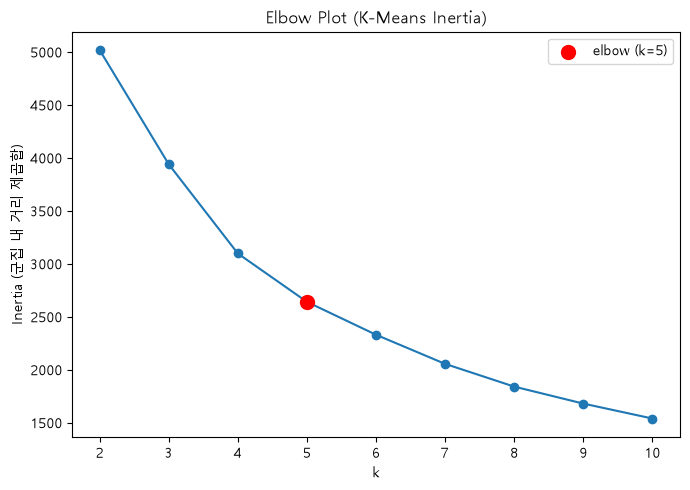

In [18]:
def find_elbow_k(k_metrics):
    k = k_metrics['k'].to_numpy(dtype=float)
    inertia = k_metrics['inertia'].to_numpy(dtype=float)
    k_norm = (k - k.min()) / (k.max() - k.min())
    inertia_norm = (inertia - inertia.min()) / (inertia.max() - inertia.min())
    x1, y1 = k_norm[0], inertia_norm[0]
    x2, y2 = k_norm[-1], inertia_norm[-1]
    distances = np.abs((y2 - y1) * k_norm - (x2 - x1) * inertia_norm + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
    return int(k[int(np.argmax(distances))])

elbow_k = find_elbow_k(k_search)
print(f"엘보우(Kneedle 방식) 추천 k = {elbow_k}")

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(k_search['k'], k_search['inertia'], marker='o')
elbow_row = k_search[k_search['k'] == elbow_k].iloc[0]
ax.scatter([elbow_k], [elbow_row['inertia']], color='red', s=100, zorder=5, label=f'elbow (k={elbow_k})')
ax.legend()
ax.set(title='Elbow Plot (K-Means Inertia)', xlabel='k', ylabel='Inertia (군집 내 거리 제곱합)')
ax.set_xticks(k_search['k'])
plt.tight_layout()
plt.show()

# 9. 초기값 안정성 확인

Silhouette이 작은 k에 유리하다는 편향을 감안해, "실루엣 상위 몇 개"가 아니라 **k=2~10 전체**에 대해 시드(무작위 초기화 기준값)를 0~9로 10번 바꿔 K-Means를 반복 실행하고, 서로 다른 시드 결과끼리 **Adjusted Rand Index(ARI)**로 재현성을 확인한다. ARI가 1에 가까울수록 "시드를 바꿔도 거의 항상 같은 군집이 나온다"는 뜻이다.

In [19]:
def stability_check(X, k, seeds=range(10), n_init=50):
    runs = [KMeans(n_clusters=k, n_init=n_init, random_state=seed).fit_predict(X) for seed in seeds]
    aris = [adjusted_rand_score(runs[i], runs[j]) for i in range(len(runs)) for j in range(i + 1, len(runs))]
    return {
        'k': k,
        '쌍별_ARI_평균': float(np.mean(aris)),
        '쌍별_ARI_최소': float(np.min(aris)),
        '쌍별_ARI_최대': float(np.max(aris)),
    }

stability = pd.DataFrame([stability_check(X, k) for k in k_search['k']])
stability

,k,쌍별_ARI_평균,쌍별_ARI_최소,쌍별_ARI_최대
0,2,0.998362,0.994607,1.000000
1,3,0.989861,0.979494,1.000000
2,4,0.998037,0.993128,1.000000
3,5,0.979471,0.951219,0.998897
4,6,0.981540,0.965884,1.000000
5,7,0.991923,0.974770,1.000000
6,8,0.952507,0.898813,1.000000
7,9,0.980319,0.949369,1.000000
8,10,0.973859,0.953806,0.996195


# 10. 결과 정리 — 최종 k 선택

**2026-09-01 팀 결정에 따른 3변수 결과**

- 최종 `per_df`의 2,223개 단지와 3개 원 변수(`세대수`, `평균전용면적`, `사용연수`)를 사용했다.
- 엘보우는 `k=5`를 추천한다.
- `k=4`, `k=5`, `k=6`의 Silhouette은 각각 약 0.314, 0.322, 0.324다. `k=6`이 약 0.0014 높지만 차이가 매우 작고, 엘보우와 설명의 간결성을 함께 고려해 `k=5`를 유지한다.
- `k=5`의 시드 간 평균 ARI는 약 0.979, 최소 ARI는 약 0.951로 초기값을 바꿔도 결과가 안정적이다.
- `k=5` 군집 크기는 최소 150개, 최대 756개다. 크기 차이는 존재하지만 가장 작은 군집도 독립적인 구조 유형을 설명할 수 있다.

따라서 해석 가능성, 엘보우, 안정성을 종합하여 **최종 `k=5`**를 채택한다. Silhouette 약 0.322는 강하게 분리된 자연 군집이라기보다 후속 관리비 비교를 위한 운영상 유사 단지군으로 해석해야 한다.

In [20]:
final_k = 5
final_km = KMeans(n_clusters=final_k, n_init=50, random_state=42)
final_labels = final_km.fit_predict(X)

unit_df_with_cluster = unit_df.copy()
unit_df_with_cluster['cluster'] = final_labels

cluster_profile = unit_df_with_cluster.groupby('cluster')[STEP1_COLS].mean()
cluster_profile['단지_수'] = unit_df_with_cluster.groupby('cluster').size()
print(f"최종 k = {final_k}")
cluster_profile

최종 k = 5


,세대수,평균전용면적,사용연수,단지_수
cluster,,,,
0,237.325397,80.942861,22.570336,756
1,903.773077,79.657083,11.027943,520
2,937.031308,78.544768,29.369221,543
3,707.822835,36.235612,22.343515,254
4,638.280000,128.106105,31.926407,150


## 10-1. 군집 시각화 (3D 원 변수 축)

PCA를 적용하지 않고 K-Means 입력과 동일한 세 원 변수로 3D 산점도를 그린다. x축 `세대수`만 로그 스케일로 표시하고, y축 `평균전용면적`과 z축 `사용연수`는 선형 스케일을 유지한다. Plotly 그래프를 마우스로 회전·확대해 군집의 겹침과 분포를 확인할 수 있다.

초대형 단지 때문에 대부분의 점이 한쪽에 압축되는 현상을 줄이기 위해 **시각화에서만 세대수 4,000 이상 단지를 제외**한다. K-Means 학습과 군집 프로파일 계산에는 전체 2,223개 단지를 그대로 사용하므로 분석 결과에는 영향을 주지 않는다.

In [21]:
# PCA 없이 세대수·평균전용면적·사용연수를 그대로 사용한 회전형 3D 시각화
import plotly.express as px

CLUSTER_NAMES = {
    0: '소단지 구축 국민평형',
    1: '대단지 신축 국민평형',
    2: '대단지 구축 국민평형',
    3: '대단지 구축 소형평형',
    4: '중단지 노후 대형평형',
}

plot_df_all = unit_df_with_cluster.reset_index()
plot_df = plot_df_all[plot_df_all['세대수'] < 4000].copy()
name_map = per_df[['단지코드', '단지명']].drop_duplicates('단지코드').set_index('단지코드')['단지명']
plot_df['단지명'] = plot_df['단지코드'].map(name_map)
plot_df['군집명'] = plot_df['cluster'].map(CLUSTER_NAMES)

excluded_for_plot = len(plot_df_all) - len(plot_df)
print(f"3D 시각화 단지 수: {len(plot_df):,}개 / 세대수 4,000 이상 제외: {excluded_for_plot:,}개")

fig = px.scatter_3d(
    plot_df,
    x='세대수', y='평균전용면적', z='사용연수',
    color='군집명',
    hover_name='단지명',
    hover_data={'단지코드': True, 'cluster': True},
    log_x=True,
    opacity=0.70,
    title='3변수 K-Means 군집 분포 (세대수 로그축, 세대수 4,000 미만 표시)',
    labels={'평균전용면적': '평균전용면적(㎡)', '사용연수': '사용연수(년)'},
)
fig.update_traces(marker={'size': 3})
fig.update_layout(height=720, legend_title_text='군집명')
fig.show()

3D 시각화 단지 수: 2,213개 / 세대수 4,000 이상 제외: 10개


**군집 해석 및 명명** (군집 번호는 재실행 환경에 따라 달라질 수 있으므로 중심 특성으로 구분한다):

2026-09-01의 3변수 K-Means 결과를 규모·평형·연식의 세 축으로 해석했다.

| cluster | 세대수 | 평균전용면적 | 사용연수 | 3축 분류 | 제안 명칭 | 단지 수 |
|---:|---:|---:|---:|---|---|---:|
| 0 | 237.3 | 80.94㎡ | 22.57년 | 중연식 · 소단지 · 국민평형 | **소단지 구축 국민평형** | 756 |
| 1 | 903.8 | 79.66㎡ | 11.03년 | 신축 · 대단지 · 국민평형 | **대단지 신축 국민평형** | 520 |
| 2 | 937.0 | 78.54㎡ | 29.37년 | 구축 · 대단지 · 국민평형 | **대단지 구축 국민평형** | 543 |
| 3 | 707.8 | 36.24㎡ | 22.34년 | 중연식 · 대단지 · 소형평형 | **대단지 구축 소형평형** | 254 |
| 4 | 638.3 | 128.11㎡ | 31.93년 | 노후 · 중대단지 · 대형평형 | **중단지 노후 대형평형** | 150 |

위 명칭은 2026-09-01 팀 확정안을 적용했다. 규모·평형·연식의 수치 구간은 이름을 이해하기 위한 보조 기준이며, 최종 명칭에서는 팀의 상대 비교 기준에 따라 중연식을 `구축`, 중대단지를 `대단지` 또는 `중단지`로 간결하게 표현했다. 따라서 재현 시에는 명칭만 보지 않고 표의 세 축 평균값을 함께 확인한다.

**결과 해석**: 3변수 `k=5`의 Silhouette은 약 0.322이고 시드 간 평균 ARI는 약 0.979다. 군집은 절대적인 아파트 유형이 아니라, 규모·평형·연식이 비슷한 단지끼리 관리비를 비교하기 위한 운영상 기준이다.

**다음 단계**: 별도의 3단계 필터링 없이 각 군집 내부에서 관리비 수준과 변화 양상을 비교한다. 승강기·주차·층수 등의 변수는 군집을 다시 나누는 필터가 아니라 비용 차이를 설명하는 참고 특성으로 사용한다. PCA는 적용하지 않았다.

## 11. 군집 내 관리비 벤치마킹 지표 — `관리비합계_perm2` 정의

2026-09-02 팀 결정에 따라, 27개 비용/시설 항목(부록 C의 G1~G5 그룹핑 + 상관관계 검증 결과)을 반영해 군집 내 비교에 쓸 `관리비합계_perm2`를 정의한다.

**그룹별 최종 반영**
- **G1 관리인력·인건비**: `인건비`, `경비비`, `청소비` 채택. 관리인원 3종(일반관리/경비관리/청소관리-인원)은 대응 비용과 상관계수 0.76~0.85로 사실상 같은 정보라 총점 계산에서 제외하고 참고 태그로만 유지한다.
- **G2 에너지·설비**: `난방비(공용)`, `전기료(공용)` 2개만 채택 (2026-09-03 재검토, [작업보고서](문서/260903_개별사용료_전용4종_삭제근거_보고서.md) 기준). 근거는 세 가지다.
  1. **정의상 문제(핵심 근거)**: `관리비.csv` 원본 스키마 자체가 `공용관리비계`와 `개별사용료계`를 분리하고, 개별사용료계 안에서 다시 공용분/전용분으로 나눈다. "전용"은 세대별 개별 계량값 — 그 세대가 난방 온도를 몇 도로 설정하는지, 온수를 얼마나 쓰는지 같은 **개별 생활 습관**이 결정한다. "공용"은 복도·계단 등 공용부 사용량으로 건물의 물리적 특성(규모·단열·설비 노후도)에 좌우되고 세대의 선택과 무관하다. 비슷한 조건의 단지끼리 객관적으로 비교하려는 지표의 목적상, 전용 항목은 "단지의 특성"이 아니라 "그 시점 입주민의 우연한 생활 패턴"을 재는 셈이 된다.
     - 보조로 공용/전용 CV(단지별 중앙값)를 비교하면 결과가 엇갈린다 — 난방비는 공용 0.764 vs 전용 1.214(가설 지지), 전기료는 공용 0.399 vs 전용 0.304(가설과 반대). 즉 통계만으로는 "전용이 항상 더 불규칙하다"를 일관되게 증명하지 못하며, **이 근거의 실제 힘은 통계가 아니라 "무엇을 측정한 값인가"라는 정의 자체**에 있다.
  2. **데이터 품질 문제**: 전용 4종 모두 0값 비율이 매우 높다 — 난방비(전용) 77.8%(단지 평균 기준 69.6%), 급탕비(전용) 69.0%(67.2%), 수도료(전용) 27.0%(19.3%), 전기료(전용) 9.1%(5.4%). 이는 난방방식에 따라 애초에 해당 계량 항목이 존재하지 않는 단지가 많기 때문이다. "단지평균 ÷ 전체평균 × 100" 단순 정규화 지수를 적용해보면, 0값이 거의 없는 인건비는 표준편차 37.5·이상치(|지수-100|>200) 7개(0.3%)인 반면, 난방비(전용)은 표준편차 173.1·이상치 397개(17.9%), 급탕비(전용)은 표준편차 155.9·이상치 396개(17.8%)로 — 0에 거대한 스파이크가 생기고 나머지는 넓게 퍼지는 기형적 분포가 된다.
  3. **용도 분리**: `per_df`에서 컬럼 자체를 삭제하지 않고 `COST_SCORE_ITEMS`(총점 계산용 리스트)에서만 뺀다. 정량 지표(단지 간 공정 비교용 총점)와 예측 모델(관리비 총액 추정)은 목적이 다르므로, 이후 회귀/머신러닝 피처로는 이 4개 컬럼을 그대로 활용할 수 있다.
- **G3 시설유지·안전**: `승강기유지비`, `수선비`, `소독비` 채택. `승강기대수`·`총주차대수`는 비용이 아니라 개수형 시설 변수라 구조변수 쪽으로 이동한다.
- **G4 장기수선·장충금**: `장충금 월부과액`만 채택. 사용연수와의 상관은 0.2 내외로 약하고 연식 구간별 평균도 비단조적이라 노후도 보정용으로는 부적합하지만, 매월 실제로 부과되는 비용이므로 총점에는 포함한다. 월사용액·총적립금액은 제외한다.
- **잡수입 월수입금액**: 비용이 아니라 수입이므로 총점 계산 대상에서 분리해 별도로 보관하고 지표에서는 제외한다.
- **기타소액계**: `제사무비`+`피복비`+`건물보험료`+`그밖의부대비용`+`생활폐기물수수료`+`입대의운영비` 6개를 합산한 1개 컬럼(`기타소액계_perm2`)으로 압축한다. 그룹 내 상관관계는 낮지만, 개별 비중이 공용관리비의 1% 안팎으로 미미해 재료성 기준으로 압축했다.

**구조변수로 이동**: `승강기대수_perm2`, `총주차대수_perm2`는 비용이 아니므로 `세대수`·`평균전용면적`·`사용연수`와 함께 구조변수 묶음으로 옮긴다.

**항목 수 참고**: 원본 비용 항목 기준으로는 G1(3)+G2(2)+G3(3)+G4(1)+기타소액계 원본(6) = 15개를 합산하며, "관리비합계에 더해지는 구성 요소" 기준으로 세면 G1(3)+G2(2)+G3(3)+G4(1)+기타소액계(1) = **10개**다.


In [22]:
# 그룹별 최종 반영 항목 (2026-09-02 팀 결정)
G1_ITEMS = ['인건비_perm2', '경비비_perm2', '청소비_perm2']
G2_ITEMS = ['난방비(공용)_perm2', '전기료(공용)_perm2']
G3_ITEMS = ['승강기유지비_perm2', '수선비_perm2', '소독비_perm2']
G4_ITEMS = ['장충금 월부과액_perm2']
G5_RAW_ITEMS = ['제사무비_perm2', '피복비_perm2', '건물보험료_perm2',
                '그밖의부대비용_perm2', '생활폐기물수수료_perm2', '입대의운영비_perm2']

# 총점에서 제외 — 참고용으로만 컬럼을 유지한다 (per_df에서 삭제하지 않음)
REFERENCE_ONLY_HEADCOUNT = ['일반관리-인원_perm2', '경비관리-인원_perm2', '청소관리-인원_perm2']  # G1과 상관 0.76~0.85로 중복
EXCLUDED_JANGCHUNG = ['장충금 월사용액_perm2', '장충금 총적립금액_perm2']  # stock/flow 성격이 달라 대표성 부족
EXCLUDED_MISC_INCOME = ['잡수입 월수입금액_perm2']  # 비용이 아니라 수입이므로 별도 보관
EXCLUDED_PRIVATE_USAGE = ['난방비(전용)_perm2', '급탕비(전용)_perm2', '전기료(전용)_perm2', '수도료(전용)_perm2']  # 2026-09-03: 개별 사용량 의존도가 커서 제외

# 구조변수로 이동 (비용 항목에서 제외)
STRUCTURAL_COLS = ['세대수', '평균전용면적', '사용연수', '승강기대수_perm2', '총주차대수_perm2']

# 기타소액계: G5 6개 항목 합산
per_df['기타소액계_perm2'] = per_df[G5_RAW_ITEMS].sum(axis=1)

# 관리비합계: G1+G2+G3+G4+기타소액계
COST_SCORE_ITEMS = G1_ITEMS + G2_ITEMS + G3_ITEMS + G4_ITEMS + ['기타소액계_perm2']
per_df['관리비합계_perm2'] = per_df[COST_SCORE_ITEMS].sum(axis=1)

print(f"관리비합계_perm2 구성 요소 수: {len(COST_SCORE_ITEMS)}개 (G1 {len(G1_ITEMS)} + G2 {len(G2_ITEMS)} + G3 {len(G3_ITEMS)} + G4 {len(G4_ITEMS)} + 기타소액계 1)")
print(f"기타소액계 원본 항목 수: {len(G5_RAW_ITEMS)}개")
print(f"총점 계산에 쓰인 원본 비용 항목 수(기타소액계 병합 전 기준): {len(G1_ITEMS) + len(G2_ITEMS) + len(G3_ITEMS) + len(G4_ITEMS) + len(G5_RAW_ITEMS)}개")
print(f"참고용으로만 유지(총점 제외): {REFERENCE_ONLY_HEADCOUNT + EXCLUDED_JANGCHUNG + EXCLUDED_MISC_INCOME + EXCLUDED_PRIVATE_USAGE}")
print(f"구조변수로 이동: {STRUCTURAL_COLS}")

per_df[['단지코드', '관리비합계_perm2', '기타소액계_perm2']].describe()


관리비합계_perm2 구성 요소 수: 10개 (G1 3 + G2 2 + G3 3 + G4 1 + 기타소액계 1)
기타소액계 원본 항목 수: 6개
총점 계산에 쓰인 원본 비용 항목 수(기타소액계 병합 전 기준): 15개
참고용으로만 유지(총점 제외): ['일반관리-인원_perm2', '경비관리-인원_perm2', '청소관리-인원_perm2', '장충금 월사용액_perm2', '장충금 총적립금액_perm2', '잡수입 월수입금액_perm2', '난방비(전용)_perm2', '급탕비(전용)_perm2', '전기료(전용)_perm2', '수도료(전용)_perm2']
구조변수로 이동: ['세대수', '평균전용면적', '사용연수', '승강기대수_perm2', '총주차대수_perm2']


,관리비합계_perm2,기타소액계_perm2
count,133380.000000,133380.000000
mean,1545.772567,71.531174
std,455.879976,34.459505
min,-2878.465721,-146.994717
25%,1272.682477,53.952280
50%,1476.486263,67.794289
75%,1724.848363,84.114472
max,8722.514028,3281.145662


## 12. 계절성 보정 — 기존 G2 6개 항목 기준 구현

`관리비합계_perm2`를 구성하는 G2 항목(난방비·급탕비·전기료·수도료) 중 계절성이 뚜렷한 항목은 원본 월별 시계열의 CV(변동계수)에 매년 반복되는 계절 파도가 그대로 섞여 들어간다 — 안정적인 단지도 겨울·여름 값 차이 때문에 CV가 크게 튀어 보인다. 전체 단지·전체 5년(60개월) 데이터를 모아 "이 달은 연중 평균보다 몇 배 더/덜 쓰는 달인지" 계절지수를 만들고, 원값을 그 지수로 나눠 계절 영향을 걷어낸다.

**대상**: G2 6개 중 계절성이 뚜렷한 5개 — 난방비(공용/전용)·급탕비(전용)·전기료(공용/전용). 수도료(전용)은 계절성이 약해 원값을 그대로 쓴다.

In [23]:
SEASONAL_ITEMS = ['난방비(공용)_perm2', '난방비(전용)_perm2', '급탕비(전용)_perm2',
                   '전기료(공용)_perm2', '전기료(전용)_perm2']

_month = per_df['발생년월(YYYYMM)'].astype(int) % 100

# 계절지수 = 전체 단지·전체기간 기준, 월별 평균 / 전체 평균
seasonal_index = {
    col: per_df.groupby(_month)[col].mean() / per_df[col].mean()
    for col in SEASONAL_ITEMS
}

seasonal_index_df = pd.DataFrame(seasonal_index)
seasonal_index_df.index.name = '월'
seasonal_index_df.round(2)

,난방비(공용)_perm2,난방비(전용)_perm2,급탕비(전용)_perm2,전기료(공용)_perm2,전기료(전용)_perm2
월,,,,,
1,2.10,2.95,1.44,1.30,0.98
2,1.73,2.26,1.38,1.19,0.90
3,1.35,1.40,1.35,0.97,0.82
4,0.79,0.51,1.12,0.90,0.82
5,0.55,0.17,0.97,0.83,0.80
6,0.39,0.04,0.70,0.87,0.91
7,0.36,0.03,0.58,0.99,1.30
8,0.32,0.03,0.49,1.07,1.62
9,0.36,0.04,0.58,0.88,1.19


In [24]:
# 원값 / 그 달의 계절지수 = 계절 영향을 뺀 보정값
for col in SEASONAL_ITEMS:
    per_df[f'{col}_계절보정'] = per_df[col] / _month.map(seasonal_index[col])

print('생성된 계절보정 컬럼:', [f'{col}_계절보정' for col in SEASONAL_ITEMS])

생성된 계절보정 컬럼: ['난방비(공용)_perm2_계절보정', '난방비(전용)_perm2_계절보정', '급탕비(전용)_perm2_계절보정', '전기료(공용)_perm2_계절보정', '전기료(전용)_perm2_계절보정']


In [25]:
def cv(series):
    m = series.mean()
    return series.std() / m if m else float('nan')

# 8월(난방비(전용) 지수가 0.03으로 가장 작은 달)에서 원값과 보정값의 흩어진 정도를 비교
aug_mask = _month == 8
aug_raw = per_df.loc[aug_mask, '난방비(전용)_perm2']
aug_corrected = per_df.loc[aug_mask, '난방비(전용)_perm2_계절보정']
print(f"8월 원값 표준편차: {aug_raw.std():.2f}  ->  보정값 표준편차: {aug_corrected.std():.2f}")
print(f"참고 — 난방비(전용) 연중 전체 원값 표준편차: {per_df['난방비(전용)_perm2'].std():.2f}")

8월 원값 표준편차: 23.48  ->  보정값 표준편차: 901.05
참고 — 난방비(전용) 연중 전체 원값 표준편차: 292.45


8월 한 달치 표준편차(901)가 연중 전체(292)보다 3배나 크게 나왔다. 8월은 전체 단지의 75%가 정확히 0원인 조용한 달인데, 지수가 0.03으로 워낙 작아 나눗셈이 원값을 33배 증폭시킨 것이다.

In [26]:
# 저신호 달(0.1 미만 지수)은 나누지 않고 NaN으로 비워 CV 계산에서 자동으로 빠지게 한다
LOW_SIGNAL_THRESHOLD = 0.1
LOW_SIGNAL_MONTHS = {col: set(idx[idx < LOW_SIGNAL_THRESHOLD].index) for col, idx in seasonal_index.items()}

for col in SEASONAL_ITEMS:
    corrected = per_df[col] / _month.map(seasonal_index[col])
    corrected = corrected.where(~_month.isin(LOW_SIGNAL_MONTHS[col]))
    per_df[f'{col}_계절보정'] = corrected

print('저신호로 제외되는 달:', {col: sorted(months) for col, months in LOW_SIGNAL_MONTHS.items() if months})

저신호로 제외되는 달: {'난방비(전용)_perm2': [6, 7, 8, 9]}


In [27]:
mean_compare = pd.DataFrame({
    col: {'원본 평균': per_df[col].mean(), '보정후 평균': per_df[f'{col}_계절보정'].mean()}
    for col in SEASONAL_ITEMS
}).T
print("평균 비교 (보정 전후 동일해야 정상):")
display(mean_compare.round(3))

cv_compare = pd.DataFrame({
    col: {
        '원본 CV 평균': per_df.groupby('단지코드')[col].apply(cv).mean(),
        '보정후 CV 평균': per_df.groupby('단지코드')[f'{col}_계절보정'].apply(cv).mean(),
    }
    for col in SEASONAL_ITEMS
}).T
cv_compare['감소율'] = (1 - cv_compare['보정후 CV 평균'] / cv_compare['원본 CV 평균'])
print("CV 비교 (단지별 평균):")
cv_compare.round(4)

평균 비교 (보정 전후 동일해야 정상):


,원본 평균,보정후 평균
난방비(공용)_perm2,47.322,47.322
난방비(전용)_perm2,101.609,101.609
급탕비(전용)_perm2,62.405,62.405
전기료(공용)_perm2,132.723,132.723
전기료(전용)_perm2,427.729,427.729


CV 비교 (단지별 평균):


,원본 CV 평균,보정후 CV 평균,감소율
난방비(공용)_perm2,0.7696,0.5225,0.3211
난방비(전용)_perm2,1.2968,0.5258,0.5945
급탕비(전용)_perm2,0.5294,0.3848,0.2731
전기료(공용)_perm2,0.5704,0.5652,0.0090
전기료(전용)_perm2,0.3915,0.2733,0.3020


5개 항목 모두 평균은 보정 전후 완전히 동일하고(계절보정은 CV 계산에만 쓴다), CV는 전기료(공용)을 빼고 27–59% 줄었다(전기료(공용)은 계절지수 진폭 자체가 원래 작아 0.9%만 줄어도 정상).

그런데 최근 12개월 기준으로 단지별 CV를 실제로 내보니, 그 과정에서 계절 보정 로직과는 무관한 이상치 세 가지가 나왔다.

1. **구조적 희소성**: 계산 자체가 안 되는(평균이 0이라 CV가 정의되지 않는) 단지 비율이 예상보다 훨씬 많았다 — 난방비(전용) 70.9%, 난방비(공용) 66.4%, 급탕비(전용) 68.4%, 수도료(전용) 20.5%, 전기료(전용) 6.6%(2,223개 단지 기준). "전용"이 붙은 항목일수록 이 비율이 높다.
2. **지속적 음수값**: 일부 단지는 특정 항목이 5년 내내 같은 달마다 마이너스다 — 예시 단지 `A13376702`의 난방비(공용)는 1월 값이 2021–2025년 순서로 -1057, -1292, -1711, -1405, -1649만원이다. 평균이 마이너스가 되면 CV(표준편차÷평균)의 부호가 뒤집혀 해석 불가능한 값이 나온다.
3. **구조 군집별 이질성**: 1단계 구조 군집(세대수·평균전용면적·사용연수 기준 5개)별로 보면 난방비(전용) 0원 비율이 51.5%(중단지 노후 대형평형)–92.0%(소단지 구축 국민평형)까지 갈리고, 계절지수 자체도 군집마다 달라 대단지 신축 국민평형의 난방비(공용) 지수는 통합 지수와 최대 0.57 차이 난다.

## 12-1. 다음 단계 반영 — "(전용)" 항목 제외 결정 (2026-09-03)

위에서 발견한 세 문제(구조적 희소성·지속적 음수값·구조 군집별 이질성)가 모두 "(전용)" 항목에 집중된 것을 근거로, 팀은 2026-09-03에 G2의 "(전용)" 4종(난방비·급탕비·전기료·수도료)을 관리비합계_perm2 계산에서 제외하기로 결정했다 — 11번 섹션 G2_ITEMS를 6개에서 2개(난방비(공용)·전기료(공용))로 축소(근거 상세: 문서/260903_개별사용료_전용4종_삭제근거_보고서.md). 이번 절에서 다룬 계절보정은 남은 "(공용)" 2종에 대해서는 그대로 유효하다. 이어지는 13번 섹션은 이 축소된 10개 항목을 기준으로 군집별 평균·CV를 계산한다.

## 13. 군집별 · 잔존 비용 항목별 평균·CV

단지별 총합(`관리비합계_perm2`)이 아니라, 군집(5개)별로 관리비합계에 남은 각 원본 비용 항목(G1 3개 + G2 2개 + G3 3개 + G4 1개 + 기타소액계 1개 = 10개)의 평균과 변동계수(CV)를 따로 계산한다. 항목별로 어느 군집이 무엇 때문에 비싼지/불안정한지 구분해서 볼 수 있다.

In [28]:
# 군집별 · 잔존 비용 항목별 평균·CV
REMAINING_COST_ITEMS = G1_ITEMS + G2_ITEMS + G3_ITEMS + G4_ITEMS + ['기타소액계_perm2']

# 1) 단지별로 각 항목의 시계열 평균·표준편차·CV 계산
item_mean = per_df.groupby('단지코드')[REMAINING_COST_ITEMS].mean()
item_std = per_df.groupby('단지코드')[REMAINING_COST_ITEMS].std()
item_cv = item_std / item_mean

# 2) 군집 라벨 결합 (unit_df_with_cluster는 단지코드 인덱스)
item_mean_c = item_mean.join(unit_df_with_cluster['cluster'])
item_cv_c = item_cv.join(unit_df_with_cluster['cluster'])

# 3) 군집별 평균 (각 단지 평균의 군집 내 평균) / 군집별 CV (각 단지 CV의 군집 내 평균)
cluster_item_mean = item_mean_c.groupby('cluster')[REMAINING_COST_ITEMS].mean()
cluster_item_cv = item_cv_c.groupby('cluster')[REMAINING_COST_ITEMS].mean()

cluster_item_mean.index = cluster_item_mean.index.map(CLUSTER_NAMES)
cluster_item_cv.index = cluster_item_cv.index.map(CLUSTER_NAMES)
cluster_item_mean.index.name = '군집명'
cluster_item_cv.index.name = '군집명'

print('군집별 · 항목별 평균 (원/㎡)')
display(cluster_item_mean.round(1))

print('군집별 · 항목별 CV (변동계수)')
display(cluster_item_cv.round(3))


군집별 · 항목별 평균 (원/㎡)


,인건비_perm2,경비비_perm2,청소비_perm2,난방비(공용)_perm2,전기료(공용)_perm2,승강기유지비_perm2,수선비_perm2,소독비_perm2,장충금 월부과액_perm2,기타소액계_perm2
군집명,,,,,,,,,,
소단지 구축 국민평형,467.7,358.2,164.1,18.2,136.3,26.6,58.5,9.0,246.2,81.5
대단지 신축 국민평형,393.1,305.8,209.3,30.9,163.8,30.6,57.8,6.3,165.6,69.7
대단지 구축 국민평형,375.4,424.8,153.4,66.8,106.3,19.1,58.7,6.6,241.3,67.2
대단지 구축 소형평형,615.4,424.4,174.2,63.6,109.8,19.9,38.3,9.6,72.1,59.2
중단지 노후 대형평형,442.0,572.8,181.9,153.1,141.6,24.1,66.3,7.1,206.8,64.4


군집별 · 항목별 CV (변동계수)


,인건비_perm2,경비비_perm2,청소비_perm2,난방비(공용)_perm2,전기료(공용)_perm2,승강기유지비_perm2,수선비_perm2,소독비_perm2,장충금 월부과액_perm2,기타소액계_perm2
군집명,,,,,,,,,,
소단지 구축 국민평형,0.079,0.075,0.088,1.700,0.577,0.247,0.602,0.102,0.214,0.188
대단지 신축 국민평형,0.078,0.071,0.076,0.798,0.492,0.150,0.602,0.127,0.274,0.163
대단지 구축 국민평형,0.076,0.072,0.071,0.242,0.623,0.279,0.502,0.091,0.173,0.180
대단지 구축 소형평형,0.084,0.074,0.092,1.203,0.627,0.177,0.746,0.302,0.204,0.256
중단지 노후 대형평형,0.077,0.074,0.088,0.327,0.520,0.227,0.527,0.123,0.196,0.216


## 14. 구간화 및 점수 부여

각 단지는 자신이 속한 구조 군집 안에서만 다른 단지들과 비교한다. 비교는 10개 비용 항목별로 독립 수행하며, 단지마다 `최근 12개월 평균값 → 군집 내 저비용 백분위 → 1~5점`을 산출한다.

- 기본 방식: 군집·항목별 균등 5분위, 낮은 비용부터 5·4·3·2·1점
- 0원 예외: 다량의 0원 동점 때문에 5분위 경계가 중복될 때만 0원 전체를 5점, 양수값을 4분위로 나눠 4·3·2·1점
- 실제 0원은 난방방식·임대형태 등 발생 원인과 무관하게 정상값으로 포함
- 동일한 값은 동일한 백분위와 점수를 유지
- 원인 미확정 음수값은 삭제하지 않고 `음수_검토필요`로 남기되 점수 계산에서는 제외

`5점`은 관리 품질이 우수하다는 의미가 아니라, 해당 항목의 관리비 부과액이 같은 군집 안에서 가장 낮은 축이라는 의미다. 최근 12개월은 현재 검토용 기본값이며, 팀 결정에 따라 `SCORE_WINDOW_MONTHS`를 변경할 수 있다.

In [29]:
# 4단계: 군집 내 단지별·항목별 백분위와 1~5점 산출
SCORE_WINDOW_MONTHS = 12
SCORE_LABELS = [5, 4, 3, 2, 1]  # 비용 오름차순: 저비용 5점 → 고비용 1점


def percentile_and_score(values):
    """한 군집의 한 비용 항목을 점수화한다.

    반환값
    -------
    percentile : 비용이 더 낮은 단지의 비율(0~100), 동점은 최저순위 기준
    score      : 5점(저비용)~1점(고비용), 결측·음수는 NA
    method     : 실제 적용된 구간화 방식
    """
    percentile = pd.Series(float('nan'), index=values.index, dtype=float)
    score = pd.Series(pd.NA, index=values.index, dtype='Int64')

    # 음수는 정산·환급 또는 데이터 오류 여부가 미확정이므로 점수에서 제외한다.
    valid = values[values.notna() & (values >= 0)]
    n_valid = len(valid)
    if n_valid == 0:
        return percentile, score, '계산불가'

    # '나보다 비용이 낮은 단지의 비율'. 동점 그룹은 모두 동일한 최저순위를 쓴다.
    if n_valid == 1:
        percentile.loc[valid.index] = 0.0
    else:
        percentile.loc[valid.index] = (
            (valid.rank(method='min') - 1) / (n_valid - 1) * 100
        )

    # 정상적인 분포에는 원래 설계한 5분위를 그대로 적용한다.
    try:
        quintile = pd.qcut(valid, 5, labels=SCORE_LABELS)
        score.loc[valid.index] = quintile.astype(int)
        return percentile, score, '일반5분위'
    except ValueError:
        pass

    # 다량의 0원 동점 때문에 5분위 경계가 중복된 경우에만 예외 규칙을 쓴다.
    zero_mask = valid == 0
    if zero_mask.any():
        score.loc[valid[zero_mask].index] = 5
        positive = valid[~zero_mask]
        if len(positive):
            try:
                positive_quartile = pd.qcut(
                    positive, 4, labels=[4, 3, 2, 1]
                )
                score.loc[positive.index] = positive_quartile.astype(int)
            except ValueError:
                # 양수 구간에도 대량 동점이 있으면 값 동점을 보존하는 고정 백분위 사용
                positive_pct = (
                    (positive.rank(method='min') - 1)
                    / max(len(positive) - 1, 1)
                )
                score.loc[positive.index] = pd.cut(
                    positive_pct,
                    bins=[-1e-12, .25, .50, .75, 1.0],
                    labels=[4, 3, 2, 1],
                    include_lowest=True,
                ).astype(int)
        return percentile, score, '0원5점_양수4분위'

    # 0원이 아닌 다른 값의 대량 동점으로 5분위가 실패한 경우의 안전장치
    fixed_pct = (valid.rank(method='min') - 1) / max(n_valid - 1, 1)
    score.loc[valid.index] = pd.cut(
        fixed_pct,
        bins=[-1e-12, .20, .40, .60, .80, 1.0],
        labels=SCORE_LABELS,
        include_lowest=True,
    ).astype(int)
    return percentile, score, '동점보존_고정백분위'


# 각 단지의 최근 N개월 평균을 계산한다. 군집은 1단계 확정 라벨을 그대로 사용한다.
score_recent = (
    per_df.sort_values('발생년월(YYYYMM)')
    .groupby('단지코드', group_keys=False)
    .tail(SCORE_WINDOW_MONTHS)
)
score_item_mean = score_recent.groupby('단지코드')[REMAINING_COST_ITEMS].mean()
score_base = score_item_mean.join(unit_df_with_cluster['cluster'])

score_detail_rows = []
score_summary_rows = []

for cluster_id, cluster_name in CLUSTER_NAMES.items():
    cluster_values = score_base[score_base['cluster'] == cluster_id]

    for item in REMAINING_COST_ITEMS:
        percentile, score, method = percentile_and_score(cluster_values[item])
        counts = score.value_counts().reindex([1, 2, 3, 4, 5], fill_value=0)

        score_summary_rows.append({
            '군집ID': cluster_id,
            '군집명': cluster_name,
            '항목': item,
            '전체단지수': len(cluster_values),
            '유효값수': int((cluster_values[item].notna() & (cluster_values[item] >= 0)).sum()),
            '결측수': int(cluster_values[item].isna().sum()),
            '음수값수': int((cluster_values[item] < 0).sum()),
            '0값수': int((cluster_values[item] == 0).sum()),
            '점수방식': method,
            '1점': int(counts[1]),
            '2점': int(counts[2]),
            '3점': int(counts[3]),
            '4점': int(counts[4]),
            '5점': int(counts[5]),
        })

        item_result = pd.DataFrame({
            '단지코드': cluster_values.index,
            '군집ID': cluster_id,
            '군집명': cluster_name,
            '항목': item,
            f'최근{SCORE_WINDOW_MONTHS}개월평균_원perm2': cluster_values[item].values,
            '군집내_저비용백분위': percentile.reindex(cluster_values.index).values,
            '점수': score.reindex(cluster_values.index).values,
            '점수방식': method,
        })
        item_result['값상태'] = '양수'
        item_result.loc[item_result[f'최근{SCORE_WINDOW_MONTHS}개월평균_원perm2'] == 0, '값상태'] = '0원'
        item_result.loc[item_result[f'최근{SCORE_WINDOW_MONTHS}개월평균_원perm2'] < 0, '값상태'] = '음수_검토필요'
        item_result.loc[item_result[f'최근{SCORE_WINDOW_MONTHS}개월평균_원perm2'].isna(), '값상태'] = '결측'
        score_detail_rows.append(item_result)

score_detail = pd.concat(score_detail_rows, ignore_index=True)
score_summary = pd.DataFrame(score_summary_rows)

# 전체 실행 검증: 행 수, 0원 처리, 음수 제외, 정상값 점수 누락, 동점 분할을 확인한다.
mean_col = f'최근{SCORE_WINDOW_MONTHS}개월평균_원perm2'
assert len(score_detail) == score_base.shape[0] * len(REMAINING_COST_ITEMS)
assert not ((score_detail['값상태'] == '0원') & (score_detail['점수'] != 5)).any()
assert not ((score_detail['값상태'] == '음수_검토필요') & score_detail['점수'].notna()).any()
assert not (score_detail['값상태'].isin(['0원', '양수']) & score_detail['점수'].isna()).any()
assert not (
    score_detail[score_detail['점수'].notna()]
    .groupby(['군집ID', '항목', mean_col])['점수']
    .nunique()
    .gt(1)
    .any()
)

score_run_summary = pd.Series({
    '평가기준': f'단지별 최근 {SCORE_WINDOW_MONTHS}개월 평균',
    '단지수': score_base.shape[0],
    '항목수': len(REMAINING_COST_ITEMS),
    '단지항목결과행수': len(score_detail),
    '군집항목조합수': len(score_summary),
    '일반5분위조합수': int((score_summary['점수방식'] == '일반5분위').sum()),
    '0원예외조합수': int((score_summary['점수방식'] == '0원5점_양수4분위').sum()),
    '결측수': int(score_summary['결측수'].sum()),
    '음수값수': int(score_summary['음수값수'].sum()),
}, name='전체 실행 결과')

display(score_run_summary.to_frame())
display(score_summary)
display(score_detail.head(20))

,전체 실행 결과
평가기준,단지별 최근 12개월 평균
단지수,2223
항목수,10
단지항목결과행수,22230
군집항목조합수,50
일반5분위조합수,44
0원예외조합수,6
결측수,0
음수값수,61


,군집ID,군집명,항목,전체단지수,유효값수,결측수,음수값수,0값수,점수방식,1점,2점,3점,4점,5점
0,0,소단지 구축 국민평형,인건비_perm2,756,756,0,0,0,일반5분위,151,151,151,151,152
1,0,소단지 구축 국민평형,경비비_perm2,756,756,0,0,13,일반5분위,151,151,151,151,152
2,0,소단지 구축 국민평형,청소비_perm2,756,756,0,0,3,일반5분위,151,151,151,151,152
3,0,소단지 구축 국민평형,난방비(공용)_perm2,756,751,0,5,641,0원5점_양수4분위,28,27,27,28,641
4,0,소단지 구축 국민평형,전기료(공용)_perm2,756,754,0,2,1,일반5분위,151,151,150,151,151
5,0,소단지 구축 국민평형,승강기유지비_perm2,756,756,0,0,10,일반5분위,151,151,151,151,152
6,0,소단지 구축 국민평형,수선비_perm2,756,755,0,1,52,일반5분위,151,151,151,151,151
7,0,소단지 구축 국민평형,소독비_perm2,756,756,0,0,8,일반5분위,151,151,151,151,152
8,0,소단지 구축 국민평형,장충금 월부과액_perm2,756,756,0,0,4,일반5분위,151,151,151,151,152
9,0,소단지 구축 국민평형,기타소액계_perm2,756,756,0,0,0,일반5분위,151,151,151,151,152


,단지코드,군집ID,군집명,항목,최근12개월평균_원perm2,군집내_저비용백분위,점수,점수방식,값상태
0,A10024667,0,소단지 구축 국민평형,인건비_perm2,388.502755,19.072848,5,일반5분위,양수
1,A10024793,0,소단지 구축 국민평형,인건비_perm2,417.374806,27.152318,4,일반5분위,양수
2,A10024811,0,소단지 구축 국민평형,인건비_perm2,425.265953,29.139073,4,일반5분위,양수
3,A10024822,0,소단지 구축 국민평형,인건비_perm2,575.634433,76.423841,2,일반5분위,양수
4,A10025157,0,소단지 구축 국민평형,인건비_perm2,572.568422,75.629139,2,일반5분위,양수
5,A10025372,0,소단지 구축 국민평형,인건비_perm2,514.414736,59.735099,3,일반5분위,양수
6,A10025710,0,소단지 구축 국민평형,인건비_perm2,713.526632,94.304636,1,일반5분위,양수
7,A10025898,0,소단지 구축 국민평형,인건비_perm2,1094.830907,99.470199,1,일반5분위,양수
8,A10026376,0,소단지 구축 국민평형,인건비_perm2,918.510449,98.543046,1,일반5분위,양수
9,A10026517,0,소단지 구축 국민평형,인건비_perm2,610.525063,83.178808,1,일반5분위,양수


## 15. 항목별 가중치 산출 — 관리비 변동 기여도 (eta²식 발상)

Todo(2026-09-03) 5번 항목. "각 항목이 전체 관리비 변동을 얼마나 설명하는가"를 14절과 같은 기준(단지별 `최근 12개월 평균`, `score_item_mean`)으로 실측한다.

`관리비합계(최근 12개월) = Σ item_i` 이므로 공분산의 선형성에 의해 다음이 항상 성립한다.

$$\mathrm{Var}(	ext{총점}) = \sum_i \mathrm{Cov}(item_i,\ 	ext{총점})$$

**가중치 = Cov(항목, 총점) ÷ Var(총점)** 로 정의하면 가중치 합이 항상 정확히 1이 되고(임의 정규화가 아니라 수학적 항등식), eta²(그룹 간 분산 ÷ 전체 분산)와 같은 논리로 "이 항목이 전체 분산 중 차지하는 몫"을 의미한다 — eta²이 범주형 그룹 간 분산 분해라면, 이것은 서로 상관된 연속형 항목들의 합에 대한 분산 분해다.

In [ ]:
def weight_from_cov(df_items):
    cov = df_items.cov()
    cov_with_total = cov.sum(axis=1)   # Cov(item_i, 총점) = Cov(item_i, sum of all items)
    var_total = cov.values.sum()        # Var(총점) = 공분산 행렬 전체 합
    return cov_with_total / var_total, var_total

# 전체(2,223개 단지) 기준 가중치
global_weight, global_var = weight_from_cov(score_item_mean)

# 검증: 공분산 행렬로 계산한 총분산이 실제 총점(최근 12개월 합)의 분산과 일치하는지 확인
total_recent = score_item_mean.sum(axis=1)
assert abs(total_recent.var() - global_var) < 1e-6, '분산 분해 검증 실패'

global_weight = global_weight.sort_values(ascending=False)
print(f"가중치 합계 = {global_weight.sum():.6f} (1.0 이어야 함)")
global_weight.round(4)

### 15-1. 군집별 가중치 재계산 — 팀 목표(군집 내 단지 비교)에는 이 값을 쓴다

13~14절의 점수 체계는 "군집 안에서만" 단지를 비교한다. 팀의 목표도 군집 내 단지 비교를 위한 정량지표 생성이므로, 가중치도 전체 2,223개 단지가 아니라 **각 군집 내부에서 독립적으로** 계산해야 앞뒤가 맞는다 — 아래에서 그 이유를 분산 구조로 설명한다.

In [ ]:
score_base_w = score_item_mean.join(unit_df_with_cluster['cluster'])

cluster_weights = {}
for cid, cname in CLUSTER_NAMES.items():
    sub = score_base_w[score_base_w['cluster'] == cid][REMAINING_COST_ITEMS]
    w, _ = weight_from_cov(sub)
    cluster_weights[cname] = w

cluster_weight_df = pd.DataFrame(cluster_weights)
cluster_weight_df['전체(글로벌)'] = global_weight
cluster_weight_df = cluster_weight_df.sort_values('전체(글로벌)', ascending=False)

cluster_weight_std = cluster_weight_df[list(CLUSTER_NAMES.values())].std(axis=1).sort_values(ascending=False)
print('항목별 군집 간 가중치 표준편차 (클수록 군집마다 중요도가 다름):')
print(cluster_weight_std.round(4))
cluster_weight_df.round(4)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

w_sorted = global_weight.sort_values()
axes[0].barh(w_sorted.index, w_sorted.values, color='#3b6fb6')
for i, v in enumerate(w_sorted.values):
    axes[0].text(v + 0.004, i, f'{v:.3f}', va='center', fontsize=8)
axes[0].set_title('전체 가중치 (2,223개 단지)')
axes[0].set_xlabel('가중치 (합계=1.0)')
axes[0].spines[['top', 'right']].set_visible(False)

cluster_cols = list(CLUSTER_NAMES.values())
order = cluster_weight_df.index
heat_data = cluster_weight_df.loc[order, cluster_cols]
im = axes[1].imshow(heat_data.values, cmap='YlOrRd', aspect='auto')
axes[1].set_xticks(range(len(cluster_cols)))
axes[1].set_xticklabels(cluster_cols, rotation=30, ha='right', fontsize=8)
axes[1].set_yticks(range(len(order)))
axes[1].set_yticklabels(order, fontsize=8)
for i in range(len(order)):
    for j in range(len(cluster_cols)):
        v = heat_data.values[i, j]
        axes[1].text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=7,
                      color='white' if v > heat_data.values.max() * 0.55 else 'black')
axes[1].set_title('군집별 가중치 (군집 안에서만 재계산)')

std_sorted = cluster_weight_std.sort_values()
colors = ['#c0392b' if v > 0.05 else '#3b6fb6' for v in std_sorted.values]
axes[2].barh(std_sorted.index, std_sorted.values, color=colors)
for i, v in enumerate(std_sorted.values):
    axes[2].text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=8)
axes[2].set_title('군집 간 가중치 변동성(표준편차)\n빨강=군집마다 중요도 다름')
axes[2].set_xlabel('5개 군집 가중치의 표준편차')
axes[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

### 15-2. 결론 — 군집별 가중치를 채택한다 (전역 가중치는 참고용)

전체 2,223개 단지로 계산한 가중치에는 서로 다른 두 가지 분산이 섞여 있다.

1. **군집 간 분산** — "왜 대단지가 소단지보다 관리비가 다른가" 같은, 1단계 군집화(세대수·평균전용면적·사용연수)에서 **이미 나눠 처리한** 차이
2. **군집 내 분산** — "같은 유형(같은 군집) 안에서 왜 이 단지가 저 단지보다 비싼가", 팀이 실제로 답하려는 질문

전역 가중치는 이 둘을 구분하지 않고 섞어서 계산한 값이다. 예를 들어 난방비(공용)의 전역 가중치(15.2%)에는 "군집마다 중앙·지역·개별난방 단지 비중이 다르다"는, 이미 군집화 단계에서 처리된 차이가 상당 부분 녹아 있다 — 그래서 군집별로 다시 계산하면 4.1%~30.6%까지 벌어진다(15-1절). 이미 군집화로 나눠놓은 차이를 가중치에 다시 섞으면, 정작 궁금한 "같은 군집 안에서의 설명력"과는 다른 것을 재는 지표가 된다.

14절 점수도 이미 군집 내부에서만 백분위를 매기므로, 가중치도 같은 기준(군집 내부)으로 맞춰야 **총점 = 점수 × 가중치** 계산이 논리적으로 일관된다.

**따라서 16절(최종 총점 생성)에서는 15-1절의 군집별 가중치(`cluster_weights`)를 그 군집 소속 단지에 적용한다.** 전역 가중치(`global_weight`)는 "군집화 자체가 관리비 항목별 중요도를 얼마나 재배열하는가"를 보여주는 참고 지표로만 남긴다.